In [1212]:
import pandas as pd
import numpy as np
import spacy
import rusyllab

from natasha import (
    Segmenter,
    MorphVocab,
    
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    NewsNERTagger,
    
    PER,
    NamesExtractor,

    Doc
)

import re
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = pd.read_csv("ru_cefr_short.csv")

In [782]:
dataset

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [7]:
dataset.loc[dataset.duplicated(), :]

,fragment,textbook-assigned cefr level
797,Она живёт в маленькой квартире вместе с матерь...,2
805,"Музыкой начала заниматься, когда мне было 5 ле...",2
814,"Музыкой начала заниматься, когда мне было 5 ле...",2
817,До мая 2007 года об этой музыкальной группе ни...,2
818,До мая 2007 года об этой музыкальной группе ни...,2
...,...,...
6585,В 1952 году Шагал женится на Ваве — Валентине ...,5
6628,В мировой эпидемии ожирения виноват не только ...,5
6731,"И честнее было бы, чтобы герой ролика плыл по ...",5
6876,"Теперь же его знает каждый ребёнок»,— говорит ...",5


In [9]:
dataset = dataset.loc[~dataset.duplicated(), :]
dataset

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [11]:
dataset["textbook-assigned cefr level"][50]

1

In [13]:
dataset["fragment"][50]

'В спальне мы отдыхаем и читаем вечером. В детской стоит кровать, стол и стул, маленький шкаф, книжные полки и музыкальный центр.'

In [458]:
dataset["textbook-assigned cefr level"].value_counts(), dataset["textbook-assigned cefr level"].value_counts(normalize=True)

(textbook-assigned cefr level
 3    2362
 4    1706
 5    1165
 2    1109
 1     763
 6     150
 Name: count, dtype: int64,
 textbook-assigned cefr level
 3    0.325569
 4    0.235148
 5    0.160579
 2    0.152860
 1    0.105169
 6    0.020675
 Name: proportion, dtype: float64)

In [446]:
dataset_2_part_1 = pd.read_csv("aggregated_results_by_ds__pool_37806285__2023_02_18.tsv", sep = "\t")
dataset_2_part_1 = dataset_2_part_1.drop("Unnamed: 3", axis = 1)
dataset_2_part_1

,INPUT:text,OUTPUT:category,CONFIDENCE:category
0,"Разглядывая их под микроскопом , мы увидим при...",[4],100.00%
1,"Иногда талантливые люди , не найдя себя в наук...",[4],100.00%
2,Кандидаты в депутаты от общественных организац...,[6],100.00%
3,"Главное , чтобы "" социальные лифты "" не остана...",[6],100.00%
4,Франция признает российских студентов и не при...,[2],100.00%
...,...,...,...
595,Характеристики солитонов при этом постоянно ме...,[5],100.00%
596,"Телефонами мы пользуемся помногу , в течение д...",[3],100.00%
597,Конкурентная оплата для преподавателя вуза в М...,[6],100.00%
598,"Главное , чтобы пункт назначения всегда был в ...",[5],100.00%


In [448]:
dataset_2_part_2 = pd.read_csv("aggregated_results_by_ds__pool_37939772__2023_02_27.tsv", sep = "\t")
dataset_2_part_2 = dataset_2_part_2.drop("Unnamed: 3", axis = 1)
dataset_2_part_2

,INPUT:text,OUTPUT:category,CONFIDENCE:category
0,"На суде он свою вину отрицал , факты у обвинен...",[5],100.00%
1,Чтобы Украину не взяли в НАТО и в Евросоюз ?,[1],100.00%
2,"Все это было свежо и ярко , много ярче , чем в...",[3],100.00%
3,Японский центр в Нижнем Новгороде открылся в п...,[1],100.00%
4,Я довольно активно участвую в борьбе за военну...,[2],100.00%
...,...,...,...
595,В 1991 - 2008 чемпионками мира ( с перерывами ...,[3],100.00%
596,То есть сейчас действительно уже можно получат...,[5],100.00%
597,"Да и понятия "" параолимпийский тренер "" в обыд...",[7],100.00%
598,Такое представление на длительное время заторм...,[5],100.00%


In [454]:
dataset_2 = pd.concat([dataset_2_part_1, dataset_2_part_2], ignore_index=True, sort=False)
dataset_2

,INPUT:text,OUTPUT:category,CONFIDENCE:category
0,"Разглядывая их под микроскопом , мы увидим при...",[4],100.00%
1,"Иногда талантливые люди , не найдя себя в наук...",[4],100.00%
2,Кандидаты в депутаты от общественных организац...,[6],100.00%
3,"Главное , чтобы "" социальные лифты "" не остана...",[6],100.00%
4,Франция признает российских студентов и не при...,[2],100.00%
...,...,...,...
1195,В 1991 - 2008 чемпионками мира ( с перерывами ...,[3],100.00%
1196,То есть сейчас действительно уже можно получат...,[5],100.00%
1197,"Да и понятия "" параолимпийский тренер "" в обыд...",[7],100.00%
1198,Такое представление на длительное время заторм...,[5],100.00%


In [468]:
dataset_2.loc[dataset_2.duplicated(), :]

,INPUT:text,OUTPUT:category,CONFIDENCE:category,length


In [460]:
dataset_2["OUTPUT:category"].value_counts(), dataset_2["OUTPUT:category"].value_counts(normalize=True)

(OUTPUT:category
 [7]    221
 [5]    207
 [3]    198
 [6]    197
 [2]    147
 [4]    140
 [1]     90
 Name: count, dtype: int64,
 OUTPUT:category
 [7]    0.184167
 [5]    0.172500
 [3]    0.165000
 [6]    0.164167
 [2]    0.122500
 [4]    0.116667
 [1]    0.075000
 Name: proportion, dtype: float64)

In [482]:
dataset_2[:50]

,INPUT:text,OUTPUT:category,CONFIDENCE:category,length
0,"Разглядывая их под микроскопом , мы увидим при...",[4],100.00%,25
1,"Иногда талантливые люди , не найдя себя в наук...",[4],100.00%,25
2,Кандидаты в депутаты от общественных организац...,[6],100.00%,25
3,"Главное , чтобы "" социальные лифты "" не остана...",[6],100.00%,30
4,Франция признает российских студентов и не при...,[2],100.00%,10
5,Об этом сообщили в понедельник в пресс-службе ...,[1],100.00%,10
6,С тех пор я в этом кабинете не появлялся .,[1],100.00%,10
7,Этот роман как раз и должен родиться на стыке .,[1],100.00%,10
8,Деревянный стол и две простые деревянные лавки...,[1],100.00%,10
9,Поэтому православной интеллигенции не может бы...,[2],100.00%,10


In [480]:
dataset_2_texts = np.array(dataset_2["INPUT:text"])
dataset_2_texts[:50]

array(['Разглядывая их под микроскопом , мы увидим привычные нам шестеренки и валы , цилиндры и поршни , пружины и клапаны , зеркала и микросхемы .',
       'Иногда талантливые люди , не найдя себя в науке и не в силах выдержать экономический стресс , уходят из археологии в бизнес и промышленность .',
       'Кандидаты в депутаты от общественных организаций в свою очередь также должны иметь в своей программе как общие , так и специфические направления депутатской деятельности .',
       'Главное , чтобы " социальные лифты " не останавливались и чтобы шанс в них пробиться был не только у тех , кто умудрился родиться в " нужной " семье .',
       'Франция признает российских студентов и не признает российские дипломы .',
       'Об этом сообщили в понедельник в пресс-службе администрации области .',
       'С тех пор я в этом кабинете не появлялся .',
       'Этот роман как раз и должен родиться на стыке .',
       'Деревянный стол и две простые деревянные лавки в углу .',
       'Поэтом

## Parsing

In [17]:
segmenter = Segmenter()
morph_vocab = MorphVocab()

emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)
ner_tagger = NewsNERTagger(emb)
names_extractor = NamesExtractor(morph_vocab)

In [18]:
dataset_np = np.array(dataset["fragment"])

In [19]:
dataset_np[6078]

'После этого начался последний штурм центральной части города, где находилась Имперская канцелярия. Всю ночь с 1 на 2 мая продолжались бои за канцелярию.'

In [20]:
text = dataset_np[6078]
doc = Doc(text)

### Segmentation

In [26]:
doc.segment(segmenter)

In [28]:
doc.tokens

[DocToken(stop=5, text='После'),
 DocToken(start=6, stop=11, text='этого'),
 DocToken(start=12, stop=19, text='начался'),
 DocToken(start=20, stop=29, text='последний'),
 DocToken(start=30, stop=35, text='штурм'),
 DocToken(start=36, stop=47, text='центральной'),
 DocToken(start=48, stop=53, text='части'),
 DocToken(start=54, stop=60, text='города'),
 DocToken(start=60, stop=61, text=','),
 DocToken(start=62, stop=65, text='где'),
 DocToken(start=66, stop=76, text='находилась'),
 DocToken(start=77, stop=86, text='Имперская'),
 DocToken(start=87, stop=97, text='канцелярия'),
 DocToken(start=97, stop=98, text='.'),
 DocToken(start=99, stop=102, text='Всю'),
 DocToken(start=103, stop=107, text='ночь'),
 DocToken(start=108, stop=109, text='с'),
 DocToken(start=110, stop=111, text='1'),
 DocToken(start=112, stop=114, text='на'),
 DocToken(start=115, stop=116, text='2'),
 DocToken(start=117, stop=120, text='мая'),
 DocToken(start=121, stop=133, text='продолжались'),
 DocToken(start=134, stop

In [30]:
doc.sents

[DocSent(stop=98, text='После этого начался последний штурм центральной ч..., tokens=[...]),
 DocSent(start=99, stop=152, text='Всю ночь с 1 на 2 мая продолжались бои за канцеля..., tokens=[...])]

### Morphology

In [33]:
doc.tag_morph(morph_tagger)

In [35]:
doc.tokens

[DocToken(stop=5, text='После', pos='ADP'),
 DocToken(start=6, stop=11, text='этого', pos='PRON', feats=<Inan,Gen,Neut,Sing>),
 DocToken(start=12, stop=19, text='начался', pos='VERB', feats=<Perf,Masc,Ind,Sing,Past,Fin,Mid>),
 DocToken(start=20, stop=29, text='последний', pos='ADJ', feats=<Nom,Pos,Masc,Sing>),
 DocToken(start=30, stop=35, text='штурм', pos='NOUN', feats=<Inan,Nom,Masc,Sing>),
 DocToken(start=36, stop=47, text='центральной', pos='ADJ', feats=<Gen,Pos,Fem,Sing>),
 DocToken(start=48, stop=53, text='части', pos='NOUN', feats=<Inan,Gen,Fem,Sing>),
 DocToken(start=54, stop=60, text='города', pos='NOUN', feats=<Inan,Gen,Masc,Sing>),
 DocToken(start=60, stop=61, text=',', pos='PUNCT'),
 DocToken(start=62, stop=65, text='где', pos='ADV', feats=<Pos>),
 DocToken(start=66, stop=76, text='находилась', pos='VERB', feats=<Imp,Fem,Ind,Sing,Past,Fin,Mid>),
 DocToken(start=77, stop=86, text='Имперская', pos='ADJ', feats=<Nom,Pos,Fem,Sing>),
 DocToken(start=87, stop=97, text='канцелярия

In [37]:
doc.sents[0].morph.print()

               После ADP
               этого PRON|Animacy=Inan|Case=Gen|Gender=Neut|Number=Sing
             начался VERB|Aspect=Perf|Gender=Masc|Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin|Voice=Mid
           последний ADJ|Case=Nom|Degree=Pos|Gender=Masc|Number=Sing
               штурм NOUN|Animacy=Inan|Case=Nom|Gender=Masc|Number=Sing
         центральной ADJ|Case=Gen|Degree=Pos|Gender=Fem|Number=Sing
               части NOUN|Animacy=Inan|Case=Gen|Gender=Fem|Number=Sing
              города NOUN|Animacy=Inan|Case=Gen|Gender=Masc|Number=Sing
                   , PUNCT
                 где ADV|Degree=Pos
          находилась VERB|Aspect=Imp|Gender=Fem|Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin|Voice=Mid
           Имперская ADJ|Case=Nom|Degree=Pos|Gender=Fem|Number=Sing
          канцелярия NOUN|Animacy=Inan|Case=Nom|Gender=Fem|Number=Sing
                   . PUNCT


### Lemmatization

In [40]:
for token in doc.tokens:
     token.lemmatize(morph_vocab)

In [42]:
print(doc.tokens[:5])
{_.text: _.lemma for _ in doc.tokens}

[DocToken(stop=5, text='После', pos='ADP', lemma='после'), DocToken(start=6, stop=11, text='этого', pos='PRON', feats=<Inan,Gen,Neut,Sing>, lemma='это'), DocToken(start=12, stop=19, text='начался', pos='VERB', feats=<Perf,Masc,Ind,Sing,Past,Fin,Mid>, lemma='начаться'), DocToken(start=20, stop=29, text='последний', pos='ADJ', feats=<Nom,Pos,Masc,Sing>, lemma='последний'), DocToken(start=30, stop=35, text='штурм', pos='NOUN', feats=<Inan,Nom,Masc,Sing>, lemma='штурм')]


{'После': 'после',
 'этого': 'это',
 'начался': 'начаться',
 'последний': 'последний',
 'штурм': 'штурм',
 'центральной': 'центральный',
 'части': 'часть',
 'города': 'город',
 ',': ',',
 'где': 'где',
 'находилась': 'находиться',
 'Имперская': 'имперский',
 'канцелярия': 'канцелярия',
 '.': '.',
 'Всю': 'весь',
 'ночь': 'ночь',
 'с': 'с',
 '1': '1',
 'на': 'на',
 '2': '2',
 'мая': 'май',
 'продолжались': 'продолжаться',
 'бои': 'бой',
 'за': 'за',
 'канцелярию': 'канцелярия'}

### Syntax parser

In [45]:
doc.parse_syntax(syntax_parser)
print(doc.tokens[:5])
doc.sents[0].syntax.print()

[DocToken(stop=5, text='После', id='1_1', head_id='1_2', rel='case', pos='ADP', lemma='после'), DocToken(start=6, stop=11, text='этого', id='1_2', head_id='1_3', rel='obl', pos='PRON', feats=<Inan,Gen,Neut,Sing>, lemma='это'), DocToken(start=12, stop=19, text='начался', id='1_3', head_id='1_0', rel='root', pos='VERB', feats=<Perf,Masc,Ind,Sing,Past,Fin,Mid>, lemma='начаться'), DocToken(start=20, stop=29, text='последний', id='1_4', head_id='1_5', rel='amod', pos='ADJ', feats=<Nom,Pos,Masc,Sing>, lemma='последний'), DocToken(start=30, stop=35, text='штурм', id='1_5', head_id='1_3', rel='nsubj', pos='NOUN', feats=<Inan,Nom,Masc,Sing>, lemma='штурм')]
          ┌► После       case
        ┌►└─ этого       obl
┌─────┌─└─── начался     
│     │   ┌► последний   amod
│   ┌─└──►└─ штурм       nsubj
│   │     ┌► центральной amod
│ ┌─└──►┌─└─ части       nmod
│ │     └──► города      nmod
│ │     ┌──► ,           punct
│ │     │ ┌► где         advmod
│ └──►┌─└─└─ находилась  acl:relcl
│     │  

### NER

In [47]:
doc.tag_ner(ner_tagger)
print(doc.spans[:5])
doc.ner.print()

[DocSpan(start=77, stop=97, type='LOC', text='Имперская канцелярия', tokens=[...])]
После этого начался последний штурм центральной части города, где 
находилась Имперская канцелярия. Всю ночь с 1 на 2 мая продолжались 
           LOC─────────────────                                     
бои за канцелярию.


## Features

### Sentence_level_complexity_Rus

In [464]:
dataset_2["length"] = dataset_2["INPUT:text"].map(lambda x: len(x.split()))

In [466]:
print(f'Среднее количество токенов в тексте: {dataset_2["length"].mean()}')
print(f'Минимальное количество токенов в тексте: {dataset_2["length"].min()}')
print(f'Максимальное количество токенов в тексте: {dataset_2["length"].max()}')

Среднее количество токенов в тексте: 22.5
Минимальное количество токенов в тексте: 10
Максимальное количество токенов в тексте: 35


### RU-CEFR-Short

In [52]:
feats_table = pd.DataFrame()

In [54]:
feats_table["length"] = dataset["fragment"].map(lambda x: len(x.split()))

In [56]:
print(f'Среднее количество токенов в тексте: {feats_table["length"].mean()}')
print(f'Минимальное количество токенов в тексте: {feats_table["length"].min()}')
print(f'Максимальное количество токенов в тексте: {feats_table["length"].max()}')

Среднее количество токенов в тексте: 24.061888352860098
Минимальное количество токенов в тексте: 15
Максимальное количество токенов в тексте: 40


In [58]:
feats_table["text"] = dataset["fragment"]
feats_table["complexity"] = dataset["textbook-assigned cefr level"]

In [60]:
sentence_test = doc.sents[0].text
sentence_test

'После этого начался последний штурм центральной части города, где находилась Имперская канцелярия.'

In [62]:
doc.sents

[DocSent(stop=98, text='После этого начался последний штурм центральной ч..., tokens=[...], spans=[...]),
 DocSent(start=99, stop=152, text='Всю ночь с 1 на 2 мая продолжались бои за канцеля..., tokens=[...])]

In [64]:
len(doc.sents[0].tokens[2].text)

7

In [66]:
from collections import Counter

In [813]:
def compute_sentence_info(sentences):
    doc_sent_info = {}
    sent_n = 1
    for sentence in sentences:
        df_tokens = {}
        df_heads = {}
        df_lengths = {}
        for token in sentence.tokens:
            df_tokens[token.id] = [token.text, token.lemma, token.head_id, token.rel, token.pos, len(token.text), len(rusyllab.split_word(token.text))]
            if token.head_id not in df_heads:
                df_heads[token.head_id] = 1
            else:
                df_heads[token.head_id] += 1

        df_heads = {x:y for x,y in df_heads.items() if not x.endswith('_0')}
        doc_sent_info[sent_n] = {"df_tokens" : df_tokens, "df_heads": df_heads}
        df_real_tokens = {key : token for key, token in doc_sent_info[sent_n]["df_tokens"].items() if not token[4] == ('PUNCT' or "SYM" or "X")} # без знаков пунктуации
        doc_sent_info[sent_n]["df_real_tokens"] = df_real_tokens

        if sent_n == 1:
            doc_sent_info[sent_n]["lemma_overlap_n"] = 0
        else:
            previous_sentence_valid_lemmas = {key : token for key, token in doc_sent_info[sent_n - 1]["df_real_tokens"].items() if token[4] in ['ADJ', "ADV", "INTJ", "NOUN", "NUM", "PROPN", "VERB"]} # без предлогов, союзов и других вспомогательных слов
            current_sentence_valid_lemmas = {key : token for key, token in doc_sent_info[sent_n]["df_real_tokens"].items() if token[4] in ['ADJ', "ADV", "INTJ", "NOUN", "NUM", "PROPN", "VERB"]}
            
            if len(current_sentence_valid_lemmas) > 0 and len(previous_sentence_valid_lemmas) > 0:
                previous_sentence_lemmas_unique = set(np.array(list(previous_sentence_valid_lemmas.values()))[:,1])
                current_sentence_lemmas_unique = set(np.array(list(current_sentence_valid_lemmas.values()))[:,1])
                
                lemma_overlap_n = len(current_sentence_lemmas_unique.intersection(previous_sentence_lemmas_unique))
                doc_sent_info[sent_n]["lemma_overlap_n"] = lemma_overlap_n
            else:
                doc_sent_info[sent_n]["lemma_overlap_n"] = 0 
        for token in sentence.tokens:
            head_id = doc_sent_info[sent_n]["df_tokens"][token.id][2]
            len_sent = 1
            tokens_done = []
            while not head_id.endswith("_0"):
                new_head_id = doc_sent_info[sent_n]["df_tokens"][head_id][2]
                if new_head_id in tokens_done:
                    doc_sent_info[sent_n]["df_heads"][new_head_id] -= 1 
                    new_head_id = str(sent_n) + "_0"
                    doc_sent_info[sent_n]["df_tokens"][head_id][2] = new_head_id
                    break
                tokens_done.append(head_id)
                head_id = new_head_id
                len_sent += 1
            df_lengths[token.id] = len_sent
        doc_sent_info[sent_n]["df_lengths"] = df_lengths

        double_child_n = Counter(doc_sent_info[sent_n]["df_heads"].values())[2]
        three_child_n = Counter(doc_sent_info[sent_n]["df_heads"].values())[3] 
        four_child_n = Counter(doc_sent_info[sent_n]["df_heads"].values())[4] 
        inner_vertices_n = len(doc_sent_info[sent_n]["df_heads"])
        vertices_n = len(doc_sent_info[sent_n]["df_real_tokens"])
        if len(doc_sent_info[sent_n]["df_heads"]) == 0:
            tree_depth = 0
        else:
            tree_depth = max(doc_sent_info[sent_n]["df_heads"].values())
        leaves_n = len(doc_sent_info[sent_n]["df_real_tokens"]) - len(doc_sent_info[sent_n]["df_heads"])
        
        dep_relations = np.array(list(doc_sent_info[sent_n]["df_real_tokens"].values()))[:,3]
        dep_relations = np.array([i.split(":")[0] for i in dep_relations])

        deps_counter = Counter(dep_relations)
        amod_n = deps_counter['amod']
        compound_n = deps_counter['compound']
        conj_n = deps_counter['conj']
        det_n = deps_counter['det']
        nmod_n = deps_counter['nmod']
        nsubj_n = deps_counter['nsubj']

        unique_deps = len(deps_counter)
    
        real_tokens_keys = np.array(list(doc_sent_info[sent_n]["df_real_tokens"].keys()))
        tokens_keys = np.array(list(doc_sent_info[sent_n]["df_tokens"].keys()))
        
        df_linear_distance = {}
        for token_id in doc_sent_info[sent_n]["df_real_tokens"]:
            token_head_id = doc_sent_info[sent_n]["df_real_tokens"][token_id][2]
            if token_head_id.endswith("_0"):
                lin_dist = 0
                pass
            else:
                if doc_sent_info[sent_n]["df_tokens"][token_head_id][4] == ('PUNCT' or "SYM" or "X"):
                    lin_dist = np.abs(np.where(real_tokens_keys == token_id)[0][0] - np.where(tokens_keys == token_head_id)[0][0])
                else:
                    lin_dist = np.abs(np.where(real_tokens_keys == token_id)[0][0] - np.where(real_tokens_keys == token_head_id)[0][0])
            df_linear_distance[token_id] = lin_dist
        
        mean_linear_distance = np.array(list(df_linear_distance.values())).mean()
        
        words_length_array = np.array(list(df_real_tokens.values()))[:,5].astype(np.int_)
        words_length_total = words_length_array.sum()

        syllables_length_array = np.array(list(df_real_tokens.values()))[:,6].astype(np.int_)
        syllables_length_total = syllables_length_array.sum()

        sentence_pos_array = np.array(list(df_real_tokens.values()))[:,4]

        pos_counter = Counter(sentence_pos_array)
        adj_n = pos_counter['ADJ']
        adp_n = pos_counter['ADP']
        adv_n = pos_counter['ADV']
        aux_n = pos_counter['AUX']
        cconj_n = pos_counter['CCONJ']
        det_pos_n = pos_counter['DET']
        intj_n = pos_counter['INTJ']
        noun_n = pos_counter['NOUN']
        num_n = pos_counter['NUM']
        part_n = pos_counter['PART']
        pron_n = pos_counter['PRON']
        propn_n = pos_counter['PROPN']
        sconj_n = pos_counter['SCONJ']
        verb_n = pos_counter['VERB']
        unique_pos = len(pos_counter)
        
        doc_sent_info[sent_n]["double_child_n"] = double_child_n
        doc_sent_info[sent_n]["three_child_n"] = three_child_n
        doc_sent_info[sent_n]["four_child_n"] = four_child_n
        doc_sent_info[sent_n]["inner_vertices_n"] = inner_vertices_n
        doc_sent_info[sent_n]["vertices_n"] = vertices_n
        doc_sent_info[sent_n]["tree_depth"] = tree_depth
        doc_sent_info[sent_n]["leaves_n"] = leaves_n
        doc_sent_info[sent_n]["amod_n"] = amod_n
        doc_sent_info[sent_n]["compound_n"] = compound_n
        doc_sent_info[sent_n]["conj_n"] = conj_n
        doc_sent_info[sent_n]["det_n"] = det_n
        doc_sent_info[sent_n]["nmod_n"] = nmod_n
        doc_sent_info[sent_n]["nsubj_n"] = nsubj_n
        doc_sent_info[sent_n]["mean_linear_distance"] = mean_linear_distance
        doc_sent_info[sent_n]["unique_deps"] = unique_deps

        doc_sent_info[sent_n]["words_length_total"] = words_length_total
        doc_sent_info[sent_n]["syllables_length_total"] = syllables_length_total

        doc_sent_info[sent_n]["adj_n"] = adj_n / vertices_n
        doc_sent_info[sent_n]["adp_n"] = adp_n / vertices_n
        doc_sent_info[sent_n]["adv_n"] = adv_n / vertices_n
        doc_sent_info[sent_n]["aux_n"] = aux_n / vertices_n
        doc_sent_info[sent_n]["cconj_n"] = cconj_n / vertices_n
        doc_sent_info[sent_n]["det_pos_n"] = det_pos_n / vertices_n
        doc_sent_info[sent_n]["intj_n"] = intj_n / vertices_n
        doc_sent_info[sent_n]["noun_n"] = noun_n / vertices_n
        doc_sent_info[sent_n]["num_n"] = num_n / vertices_n
        doc_sent_info[sent_n]["part_n"] = part_n / vertices_n
        doc_sent_info[sent_n]["pron_n"] = pron_n / vertices_n
        doc_sent_info[sent_n]["propn_n"] = propn_n / vertices_n
        doc_sent_info[sent_n]["sconj_n"] = sconj_n / vertices_n
        doc_sent_info[sent_n]["verb_n"] = verb_n / vertices_n
        doc_sent_info[sent_n]["unique_pos"] = unique_pos
        
        sent_n +=1
    return doc_sent_info

In [815]:
compute_sentence_info(doc.sents)

{1: {'df_tokens': {'1_1': ['После', 'после', '1_2', 'case', 'ADP', 5, 2],
   '1_2': ['этого', 'это', '1_3', 'obl', 'PRON', 5, 3],
   '1_3': ['начался', 'начаться', '1_0', 'root', 'VERB', 7, 3],
   '1_4': ['последний', 'последний', '1_5', 'amod', 'ADJ', 9, 3],
   '1_5': ['штурм', 'штурм', '1_3', 'nsubj', 'NOUN', 5, 1],
   '1_6': ['центральной', 'центральный', '1_7', 'amod', 'ADJ', 11, 3],
   '1_7': ['части', 'часть', '1_5', 'nmod', 'NOUN', 5, 2],
   '1_8': ['города', 'город', '1_7', 'nmod', 'NOUN', 6, 3],
   '1_9': [',', ',', '1_11', 'punct', 'PUNCT', 1, 1],
   '1_10': ['где', 'где', '1_11', 'advmod', 'ADV', 3, 1],
   '1_11': ['находилась', 'находиться', '1_7', 'acl:relcl', 'VERB', 10, 4],
   '1_12': ['Имперская', 'имперский', '1_13', 'amod', 'ADJ', 9, 4],
   '1_13': ['канцелярия', 'канцелярия', '1_11', 'nsubj', 'NOUN', 10, 5],
   '1_14': ['.', '.', '1_3', 'punct', 'PUNCT', 1, 1]},
  'df_heads': {'1_2': 1, '1_3': 3, '1_5': 2, '1_7': 3, '1_11': 3, '1_13': 1},
  'df_real_tokens': {'1_1': 

In [936]:
def compute_sentence_features(sentence_info):
    double_child = []
    inner_vertices = []
    vertices = []
    tree_depth = []
    amod = []
    compound = []
    conj = []
    det = []
    nmod = []
    nsubj = []
    leaves = []
    mean_linear_distance = []
    unique_deps = []
    lw = []
    sw = []

    adj = []
    adp = []
    adv = []
    aux = []
    cconj = []
    det_pos = []
    intj = []
    noun = []
    num = []
    part = []
    pron = []
    propn = []
    sconj = []
    verb = []
    unique_pos = []

    lemma_overlap = []
    
    for d in sentence_info.values():
        double_child.append(d["double_child_n"])
        inner_vertices.append(d["inner_vertices_n"])
        vertices.append(d["vertices_n"])
        tree_depth.append(d["tree_depth"])
        amod.append(d["amod_n"])
        compound.append(d["compound_n"])
        conj.append(d["conj_n"])
        det.append(d["det_n"])
        nmod.append(d["nmod_n"])
        nsubj.append(d["nsubj_n"])
        leaves.append(d["leaves_n"])
        mean_linear_distance.append(d["mean_linear_distance"])
        unique_deps.append(d["unique_deps"])

        adj.append(d["adj_n"])
        adp.append(d["adp_n"])
        adv.append(d["adv_n"])
        aux.append(d["aux_n"])
        cconj.append(d["cconj_n"])
        det_pos.append(d["det_pos_n"])
        intj.append(d["intj_n"])
        noun.append(d["noun_n"])
        num.append(d["num_n"])
        part.append(d["part_n"])
        pron.append(d["pron_n"])
        propn.append(d["propn_n"])
        sconj.append(d["sconj_n"])
        verb.append(d["verb_n"])
        unique_pos.append(d["unique_pos"])

        lw.append(d["words_length_total"])
        sw.append(d["syllables_length_total"])

        lemma_overlap.append(d["lemma_overlap_n"])

    sum_length = np.sum(vertices)
    avg_double_child = np.mean(double_child)
    avg_inner_vertices = np.mean(inner_vertices)
    avg_vertices = np.mean(vertices)
    avg_tree_depth = np.mean(tree_depth)
    avg_amod = np.mean(amod)
    avg_compound = np.mean(compound)
    avg_conj = np.mean(conj)
    avg_det = np.mean(det)
    avg_nmod = np.mean(nmod)
    avg_nsubj = np.mean(nsubj)
    avg_unique_deps = np.mean(unique_deps)
    max_leaves = np.max(leaves)
    max_inner_vertices = np.max(inner_vertices)
    max_vertices = np.max(vertices)
    max_unique_deps = np.max(unique_deps)
    median_nmod = np.median(nmod)
    median_inner_vertices = np.median(inner_vertices)
    median_vertices = np.median(vertices)
    std_leaves = np.std(leaves)
    std_vertices = np.std(vertices)
    std_conj = np.std(conj)
    std_det = np.std(det)
    std_mean_linear_distance = np.std(mean_linear_distance)

    avg_adj = np.mean(adj)
    avg_adp = np.mean(adp)
    avg_adv = np.mean(adv)
    avg_aux = np.mean(aux)
    avg_cconj = np.mean(cconj)
    avg_det_pos = np.mean(det_pos)
    avg_intj = np.mean(intj)
    avg_noun = np.mean(noun)
    avg_num = np.mean(num)
    avg_part = np.mean(part)
    avg_pron = np.mean(pron)
    avg_propn = np.mean(propn)
    avg_sconj = np.mean(sconj)
    avg_verb = np.mean(verb)
    avg_unique_pos = np.mean(unique_pos)
    max_unique_pos = np.max(unique_pos)

    alw = np.sum(lw) / np.sum(vertices)
    asw = np.sum(sw) / np.sum(vertices)

    avg_lemma_overlap = np.mean(lemma_overlap)
    median_lemma_overlap = np.median(lemma_overlap)
    max_lemma_overlap = np.max(lemma_overlap)

    return {
        "avg_double_child": avg_double_child,
        "avg_inner_vertices": avg_inner_vertices,
        "avg_vertices": avg_vertices,
        "avg_tree_depth": avg_tree_depth,
        "avg_amod": avg_amod,
        "avg_compound": avg_compound,
        "avg_conj": avg_conj,
        "avg_det": avg_det,
        "avg_nmod": avg_nmod,
        "avg_nsubj": avg_nsubj,
        "avg_unique_deps": avg_unique_deps,
        "max_leaves": max_leaves,
        "max_inner_vertices": max_inner_vertices,
        "max_vertices": max_vertices,
        "max_unique_deps": max_unique_deps,
        "median_nmod": median_nmod,
        "median_inner_vertices": median_inner_vertices,
        "median_vertices": median_vertices,
        "std_leaves": std_leaves,
        "std_vertices": std_vertices,
        "std_conj": std_conj,
        "std_det": std_det,
        "std_mean_linear_distance": std_mean_linear_distance,
        "avg_adj": avg_adj,
        "avg_adp": avg_adp,
        "avg_adv": avg_adv,
        "avg_aux": avg_aux,
        "avg_cconj": avg_cconj,
        "avg_det_pos": avg_det_pos,
        "avg_intj": avg_intj,
        "avg_noun": avg_noun,
        "avg_num": avg_num,
        "avg_part": avg_part,
        "avg_pron": avg_pron,
        "avg_propn": avg_propn,
        "avg_sconj": avg_sconj,
        "avg_verb": avg_verb,
        "avg_unique_pos": avg_unique_pos,
        "max_unique_pos": max_unique_pos,
        "asw": asw,
        "alw": alw,
        "avg_lemma_overlap": avg_lemma_overlap,
        "max_lemma_overlap": max_lemma_overlap

    }

In [938]:
def extract_features(text, segmenter=Segmenter(),
                     morph_vocab=MorphVocab(),
                     emb=NewsEmbedding(),
                     morph_tagger=NewsMorphTagger(emb),
                     syntax_parser=NewsSyntaxParser(emb),
                     ner_tagger=NewsNERTagger(emb), 
                     names_extractor=NamesExtractor(morph_vocab)):
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    for token in doc.tokens:
        token.lemmatize(morph_vocab)
    doc.parse_syntax(syntax_parser)
    doc.tag_ner(ner_tagger)

    sentences = doc.sents
    sentence_info = compute_sentence_info(sentences)
    sentence_features = compute_sentence_features(sentence_info)
    features_df = sentence_features

    return features_df

In [940]:
apply_df = feats_table.apply(lambda x: extract_features(x["text"]), axis=1, result_type="expand")

In [941]:
feats_table.loc[feats_table["text"] == "), стиль (одежда, её опрятность и уместность). И что важнее — большой вопрос. «Я считаю, что для карьерного роста главное — профессиональные навыки и знания."]

,length,text,complexity
5931,25,"), стиль (одежда, её опрятность и уместность)....",4


In [942]:
feats_table_final = pd.concat([feats_table, apply_df], axis=1)

In [943]:
feats_table_final

,length,text,complexity,avg_double_child,avg_inner_vertices,avg_vertices,avg_tree_depth,avg_amod,avg_compound,avg_conj,...,avg_pron,avg_propn,avg_sconj,avg_verb,avg_unique_pos,max_unique_pos,asw,alw,avg_lemma_overlap,max_lemma_overlap
0,28,"Весной, летом и осенью почти каждую субботу он...",1,0.250000,3.75,7.000000,4.25,0.25,0.0,0.500000,...,0.162608,0.000000,0.000000,0.162608,5.25,7.0,1.892857,4.214286,0.00,0.0
1,27,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,0.500000,2.50,6.750000,4.25,0.25,0.0,0.250000,...,0.066667,0.000000,0.041667,0.158333,4.75,6.0,2.222222,5.037037,1.00,2.0
2,28,На каждой двери красные плакаты и красные фона...,1,1.000000,3.00,7.000000,3.25,1.50,0.0,0.500000,...,0.093750,0.000000,0.031250,0.062500,5.25,6.0,2.178571,4.892857,0.25,1.0
3,26,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,0.333333,4.00,8.666667,4.00,0.00,0.0,0.666667,...,0.075397,0.000000,0.000000,0.150794,5.00,6.0,1.961538,3.846154,0.00,0.0
4,29,Магазин «Чёрный квадрат» открывается в 9 часов...,1,0.250000,3.50,7.250000,3.75,0.25,0.0,0.250000,...,0.066964,0.000000,0.000000,0.098214,5.00,5.0,2.206897,4.689655,0.50,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7317,27,Утечка мозгов стала ключевым трендом междунаро...,6,3.000000,7.50,13.500000,4.00,2.50,0.0,0.000000,...,0.033333,0.033333,0.000000,0.141667,6.00,9.0,3.111111,6.962963,0.00,0.0
7318,27,"По оценкам менеджеров «Промы», такая ситуация ...",6,4.000000,14.00,27.000000,5.00,2.00,0.0,0.000000,...,0.000000,0.074074,0.037037,0.037037,9.00,9.0,2.481481,5.444444,0.00,0.0
7319,29,"Но это не мы, а техно-мемы заполоняют мир благ...",6,1.000000,5.50,14.500000,5.50,0.50,0.0,2.500000,...,0.200980,0.000000,0.041667,0.171569,7.50,8.0,2.965517,6.103448,0.00,0.0
7320,20,Mapillary использует программное обеспечение д...,6,1.500000,5.00,10.000000,4.00,2.00,0.0,1.000000,...,0.000000,0.035714,0.035714,0.190476,6.00,7.0,4.150000,8.500000,0.00,0.0


In [944]:
feats_table_final.loc[feats_table_final['complexity'] == 6, 'complexity'] = 5

In [945]:
feats_table_final['complexity'] -= 1
feats_table_final

,length,text,complexity,avg_double_child,avg_inner_vertices,avg_vertices,avg_tree_depth,avg_amod,avg_compound,avg_conj,...,avg_pron,avg_propn,avg_sconj,avg_verb,avg_unique_pos,max_unique_pos,asw,alw,avg_lemma_overlap,max_lemma_overlap
0,28,"Весной, летом и осенью почти каждую субботу он...",0,0.250000,3.75,7.000000,4.25,0.25,0.0,0.500000,...,0.162608,0.000000,0.000000,0.162608,5.25,7.0,1.892857,4.214286,0.00,0.0
1,27,"Все говорят, что мама хорошая хозяйка. А ещё н...",0,0.500000,2.50,6.750000,4.25,0.25,0.0,0.250000,...,0.066667,0.000000,0.041667,0.158333,4.75,6.0,2.222222,5.037037,1.00,2.0
2,28,На каждой двери красные плакаты и красные фона...,0,1.000000,3.00,7.000000,3.25,1.50,0.0,0.500000,...,0.093750,0.000000,0.031250,0.062500,5.25,6.0,2.178571,4.892857,0.25,1.0
3,26,"Я считаю деньги, в час обедаю в кафе, а потом ...",0,0.333333,4.00,8.666667,4.00,0.00,0.0,0.666667,...,0.075397,0.000000,0.000000,0.150794,5.00,6.0,1.961538,3.846154,0.00,0.0
4,29,Магазин «Чёрный квадрат» открывается в 9 часов...,0,0.250000,3.50,7.250000,3.75,0.25,0.0,0.250000,...,0.066964,0.000000,0.000000,0.098214,5.00,5.0,2.206897,4.689655,0.50,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7317,27,Утечка мозгов стала ключевым трендом междунаро...,4,3.000000,7.50,13.500000,4.00,2.50,0.0,0.000000,...,0.033333,0.033333,0.000000,0.141667,6.00,9.0,3.111111,6.962963,0.00,0.0
7318,27,"По оценкам менеджеров «Промы», такая ситуация ...",4,4.000000,14.00,27.000000,5.00,2.00,0.0,0.000000,...,0.000000,0.074074,0.037037,0.037037,9.00,9.0,2.481481,5.444444,0.00,0.0
7319,29,"Но это не мы, а техно-мемы заполоняют мир благ...",4,1.000000,5.50,14.500000,5.50,0.50,0.0,2.500000,...,0.200980,0.000000,0.041667,0.171569,7.50,8.0,2.965517,6.103448,0.00,0.0
7320,20,Mapillary использует программное обеспечение д...,4,1.500000,5.00,10.000000,4.00,2.00,0.0,1.000000,...,0.000000,0.035714,0.035714,0.190476,6.00,7.0,4.150000,8.500000,0.00,0.0


In [946]:
feats_table_final["length"] = feats_table_final["text"].map(lambda x: len(x.split()))

In [1506]:
columns = np.array(feats_table_final.drop(columns=["text", "complexity", "length"]).columns)
feats_1 = feats_table_final.loc[round(feats_table_final["complexity"]) == 0].drop("text", axis=1)
feats_2 = feats_table_final.loc[round(feats_table_final["complexity"]) == 1].drop("text", axis=1)
feats_3 = feats_table_final.loc[round(feats_table_final["complexity"]) == 2].drop("text", axis=1)
feats_4 = feats_table_final.loc[round(feats_table_final["complexity"]) == 3].drop("text", axis=1)
feats_5 = feats_table_final.loc[round(feats_table_final["complexity"]) == 4].drop("text", axis=1)
feats_overall = feats_table_final.drop("text", axis=1)
all_feats = [feats_1.mean(), feats_2.mean(),  feats_3.mean(),  feats_4.mean(),  feats_5.mean(), feats_overall.mean()]
feats_df = pd.DataFrame(all_feats).transpose()
feats_df.columns = [0, 1, 2, 3, 4, "Общее"]
feats_df.round(2)

,0,1,2,3,4,Общее
length,24.95,24.44,24.08,23.75,23.59,24.06
complexity,0.00,1.00,2.00,3.00,4.00,2.23
avg_double_child,0.83,1.18,1.61,1.84,2.03,1.59
avg_inner_vertices,4.26,5.34,6.47,7.03,7.63,6.41
avg_vertices,9.21,11.62,13.42,14.42,15.79,13.36
avg_tree_depth,4.37,4.67,4.72,4.80,4.98,4.74
avg_amod,0.60,0.83,1.28,1.60,1.69,1.29
avg_compound,0.00,0.00,0.00,0.00,0.00,0.00
avg_conj,0.87,0.86,0.92,1.09,0.96,0.95
avg_det,0.21,0.29,0.38,0.38,0.50,0.37


### Обучение

In [1038]:
from sklearn import preprocessing

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report

from catboost import CatBoostClassifier


In [1040]:
y = np.array(feats_table_final["complexity"])
X = np.array(feats_table_final.drop(columns=["text", "complexity"]))

In [1042]:
X.shape

(7255, 44)

#### train_test split

In [951]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=52)

X_train_basic = 206.835 - 1.52 * X_train[:, 3:4] - 65.14 * X_train[:, -4:-3]
X_test_basic = 206.835 - 1.52 * X_test[:, 3:4] - 65.14 * X_test[:, -4:-3]

In [952]:
y_test

array([1, 4, 0, ..., 3, 1, 1], dtype=int64)

#### Logistic regression

In [1214]:
log_reg = LogisticRegression(
    max_iter=500,
    random_state=52
)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_round = np.round(y_pred)

In [1216]:
print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.46      0.42      0.44       156
           1       0.37      0.28      0.32       215
           2       0.42      0.64      0.51       483
           3       0.41      0.27      0.33       344
           4       0.48      0.34      0.40       253

    accuracy                           0.42      1451
   macro avg       0.43      0.39      0.40      1451
weighted avg       0.42      0.42      0.41      1451



In [1232]:
log_reg_basic = LogisticRegression(
    max_iter=500,
    random_state=52
)

log_reg_basic.fit(X_train_basic, y_train)

y_pred_basic = log_reg_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

In [1234]:
print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.44      0.36      0.40       156
           1       0.32      0.17      0.22       215
           2       0.37      0.78      0.50       483
           3       0.38      0.07      0.12       344
           4       0.42      0.21      0.28       253

    accuracy                           0.38      1451
   macro avg       0.39      0.32      0.30      1451
weighted avg       0.38      0.38      0.32      1451



In [1218]:
C_list = [0.01, 0.1, 1, 10, 100]
solver_list = ["lbfgs", "saga", "newton-cholesky"]

best_model_params = [0.01, "lbfgs"]
best_f1 = 0.40
model_best = None

In [1220]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for C in C_list:
    for solver in solver_list:
        etap +=1
        model_new = LogisticRegression(max_iter = 500, random_state = 52, C=C, solver=solver)
        model_new.fit(X_train, y_train)
        preds_new = model_new.predict(X_test)
        f1_new = f1_score(y_test, preds_new, average = "weighted")
        if f1_new > best_f1:
            print(etap)
            best_model_params = [C, solver]
            best_f1 = f1_new
            model_best = model_new
            print(f"So far best weighted f1-score on validation: {best_f1}, params: C = {C}, solver = {solver}")

7
So far best weighted f1-score on validation: 0.4093083444033352, params: C = 1, solver = lbfgs
10
So far best weighted f1-score on validation: 0.41471727956606624, params: C = 10, solver = lbfgs
12
So far best weighted f1-score on validation: 0.4216230606813018, params: C = 10, solver = newton-cholesky
15
So far best weighted f1-score on validation: 0.4218351919535742, params: C = 100, solver = newton-cholesky


In [1240]:
best_C = best_model_params[0]
best_solver = best_model_params[1]

In [1244]:
lr_model_best = LogisticRegression(max_iter = 500,
                                random_state = 52,
                                C=best_C, 
                                solver=best_solver)

lr_model_best.fit(X_train, y_train)
y_pred = lr_model_best.predict(X_test)
y_pred_round = np.round(y_pred)

print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.49      0.51      0.50       156
           1       0.48      0.28      0.36       215
           2       0.41      0.66      0.51       483
           3       0.43      0.26      0.33       344
           4       0.46      0.34      0.39       253

    accuracy                           0.44      1451
   macro avg       0.46      0.41      0.42      1451
weighted avg       0.45      0.44      0.42      1451



In [1252]:
best_model_params_basic = [0.01, "lbfgs"]
best_f1_basic = 0.30
model_best_basic = None

In [1254]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for C in C_list:
    for solver in solver_list:
        etap +=1
        model_new = LogisticRegression(max_iter = 500, random_state = 52, C=C, solver=solver)
        model_new.fit(X_train_basic, y_train)
        preds_new = model_new.predict(X_test_basic)
        f1_new = f1_score(y_test, preds_new, average = "weighted")
        if f1_new > best_f1_basic:
            print(etap)
            best_model_params_basic = [C, solver]
            best_f1_basic = f1_new
            model_best_basic = model_new
            print(f"So far best weighted f1-score on validation: {best_f1_basic}, params: C = {C}, solver = {solver}")

1
So far best weighted f1-score on validation: 0.3194505298204157, params: C = 0.01, solver = lbfgs


In [1260]:
best_C_basic = best_model_params_basic[0]
best_solver_basic = best_model_params_basic[1]

In [1262]:
lr_model_best_basic = LogisticRegression(max_iter = 500,
                                random_state = 52,
                                C=best_C_basic, 
                                solver=best_solver_basic)

lr_model_best_basic.fit(X_train_basic, y_train)
y_pred_basic = lr_model_best_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.44      0.36      0.40       156
           1       0.32      0.17      0.22       215
           2       0.37      0.78      0.50       483
           3       0.38      0.07      0.12       344
           4       0.42      0.21      0.28       253

    accuracy                           0.38      1451
   macro avg       0.39      0.32      0.30      1451
weighted avg       0.38      0.38      0.32      1451



### KNN

In [1268]:
knn = KNeighborsClassifier(
    n_neighbors=15
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_pred_round = np.round(y_pred)

In [1270]:
print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.44      0.33      0.37       156
           1       0.26      0.19      0.22       215
           2       0.36      0.58      0.45       483
           3       0.33      0.25      0.29       344
           4       0.38      0.21      0.27       253

    accuracy                           0.35      1451
   macro avg       0.35      0.31      0.32      1451
weighted avg       0.35      0.35      0.34      1451



In [1272]:
knn_basic = KNeighborsClassifier(
    n_neighbors=15
)


knn_basic.fit(X_train_basic, y_train)

y_pred_basic = knn_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

In [1274]:
print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.34      0.33      0.33       156
           1       0.27      0.28      0.28       215
           2       0.38      0.54      0.45       483
           3       0.32      0.24      0.27       344
           4       0.36      0.17      0.23       253

    accuracy                           0.34      1451
   macro avg       0.33      0.31      0.31      1451
weighted avg       0.34      0.34      0.33      1451



In [1294]:
n_neighbors_list = [3, 5, 7, 10, 15, 25]
weights_list = ['uniform', 'distance']
metric_list = ['euclidean', 'manhattan', "minkowski"]

best_model_params = [3, "uniform", "euclidean"]
best_f1 = 0.33
model_best = None

In [1296]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for n_neighbors in n_neighbors_list:
    for weights in weights_list:
        for metric in metric_list:
            etap +=1
            model_new = KNeighborsClassifier(n_neighbors = n_neighbors, weights = weights, metric = metric)
            model_new.fit(X_train, y_train)
            preds_new = model_new.predict(X_test)
            f1_new = f1_score(y_test, preds_new, average = "weighted")
            if f1_new > best_f1:
                print(etap)
                best_model_params = [n_neighbors, weights, metric]
                best_f1 = f1_new
                model_best = model_new
                print(f"So far best weighted f1-score on validation: {best_f1}, params: n_neighbors = {n_neighbors}, weights = {weights}, metric = {metric}")

17
So far best weighted f1-score on validation: 0.3365133854368172, params: n_neighbors = 7, weights = distance, metric = manhattan
23
So far best weighted f1-score on validation: 0.3398112898292947, params: n_neighbors = 10, weights = distance, metric = manhattan


In [1298]:
best_n_neighbors = best_model_params[0]
best_weights = best_model_params[1]
best_metric = best_model_params[2]

In [1300]:
knn_model_best = KNeighborsClassifier(n_neighbors = best_n_neighbors,
                                weights = best_weights,
                                metric=best_metric)

knn_model_best.fit(X_train, y_train)
y_pred = knn_model_best.predict(X_test)
y_pred_round = np.round(y_pred)

print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.46      0.33      0.39       156
           1       0.29      0.22      0.25       215
           2       0.38      0.53      0.44       483
           3       0.30      0.28      0.29       344
           4       0.32      0.23      0.27       253

    accuracy                           0.35      1451
   macro avg       0.35      0.32      0.33      1451
weighted avg       0.34      0.35      0.34      1451



In [1304]:
best_model_params_basic = [3, "uniform", "euclidean"]
best_f1_basic = 0.32
model_best_basic = None

In [1306]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for n_neighbors in n_neighbors_list:
    for weights in weights_list:
        for metric in metric_list:
            etap +=1
            model_new = KNeighborsClassifier(n_neighbors = n_neighbors, weights = weights, metric = metric)
            model_new.fit(X_train_basic, y_train)
            preds_new = model_new.predict(X_test_basic)
            f1_new = f1_score(y_test, preds_new, average = "weighted")
            if f1_new > best_f1_basic:
                print(etap)
                best_model_params_basic = [n_neighbors, weights, metric]
                best_f1_basic = f1_new
                model_best_basic = model_new
                print(f"So far best weighted f1-score on validation: {best_f1_basic}, params: n_neighbors = {n_neighbors}, weights = {weights}, metric = {metric}")

19
So far best weighted f1-score on validation: 0.3331423249136834, params: n_neighbors = 10, weights = uniform, metric = euclidean


In [1308]:
best_n_neighbors_basic = best_model_params_basic[0]
best_weights_basic = best_model_params_basic[1]
best_metric_basic = best_model_params_basic[2]

In [1310]:
knn_model_best_basic = KNeighborsClassifier(n_neighbors = best_n_neighbors_basic,
                                weights = best_weights_basic,
                                metric=best_metric_basic)

knn_model_best_basic.fit(X_train_basic, y_train)
y_pred_basic = knn_model_best_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.31      0.35      0.33       156
           1       0.27      0.29      0.28       215
           2       0.39      0.52      0.45       483
           3       0.32      0.26      0.29       344
           4       0.32      0.17      0.22       253

    accuracy                           0.34      1451
   macro avg       0.32      0.32      0.31      1451
weighted avg       0.34      0.34      0.33      1451



#### Random Forest

In [1099]:
rf = RandomForestClassifier(
    n_estimators=150,
    random_state=52
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_round = np.round(y_pred)

In [1100]:
print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.52      0.41      0.46       156
           1       0.38      0.30      0.34       215
           2       0.38      0.61      0.47       483
           3       0.36      0.23      0.28       344
           4       0.44      0.27      0.34       253

    accuracy                           0.39      1451
   macro avg       0.41      0.37      0.38      1451
weighted avg       0.40      0.39      0.38      1451



In [1314]:
rf_basic = RandomForestClassifier(
    n_estimators=150,
    random_state=52
)

rf_basic.fit(X_train_basic, y_train)

y_pred_basic = rf_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.33      0.26      0.29       156
           1       0.22      0.22      0.22       215
           2       0.37      0.43      0.40       483
           3       0.27      0.26      0.27       344
           4       0.28      0.23      0.25       253

    accuracy                           0.31      1451
   macro avg       0.29      0.28      0.29      1451
weighted avg       0.30      0.31      0.30      1451



In [1342]:
n_estimators_list = [150, 250, 500]
max_depth_list = [5, 10, None]
min_samples_split_list = [2, 5]

best_model_params = [150, 5, 2]
best_f1 = 0.37
model_best = None

In [1346]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_split in min_samples_split_list:
            etap +=1
            model_new = RandomForestClassifier(n_estimators = n_estimators, max_depth = max_depth, min_samples_split = min_samples_split, random_state=52)
            model_new.fit(X_train, y_train)
            preds_new = model_new.predict(X_test)
            f1_new = f1_score(y_test, preds_new, average = "weighted")
            if f1_new > best_f1:
                print(etap)
                best_model_params = [n_estimators, max_depth, min_samples_split]
                best_f1 = f1_new
                model_best = model_new
                print(f"So far best weighted f1-score on validation: {best_f1}, params: n_estimators = {n_estimators}, max_depth = {max_depth}, min_samples_split = {min_samples_split}")

3
So far best weighted f1-score on validation: 0.3836321778122861, params: n_estimators = 150, max_depth = 10, min_samples_split = 2
6
So far best weighted f1-score on validation: 0.3999101316155226, params: n_estimators = 150, max_depth = None, min_samples_split = 5
12
So far best weighted f1-score on validation: 0.40173453762637196, params: n_estimators = 250, max_depth = None, min_samples_split = 5


In [1347]:
best_n_estimators= best_model_params[0]
best_max_depth = best_model_params[1]
best_min_samples_split = best_model_params[2]

In [1348]:
rf_model_best = RandomForestClassifier(n_estimators = best_n_estimators,
                                       max_depth = best_max_depth,
                                       min_samples_split = best_min_samples_split,
                                       random_state=52)

rf_model_best.fit(X_train, y_train)
y_pred = rf_model_best.predict(X_test)
y_pred_round = np.round(y_pred)

print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.55      0.41      0.47       156
           1       0.39      0.31      0.35       215
           2       0.40      0.63      0.48       483
           3       0.40      0.28      0.33       344
           4       0.45      0.28      0.35       253

    accuracy                           0.41      1451
   macro avg       0.44      0.38      0.40      1451
weighted avg       0.42      0.41      0.40      1451



In [1349]:
best_model_params_basic = [150, 5, 2]
best_f1_basic = 0.29
model_best_basic = None

In [1354]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        for min_samples_split in min_samples_split_list:
            etap +=1
            model_new = RandomForestClassifier(n_estimators = n_estimators, max_depth = max_depth, min_samples_split = min_samples_split, random_state=52)
            model_new.fit(X_train_basic, y_train)
            preds_new = model_new.predict(X_test_basic)
            f1_new = f1_score(y_test, preds_new, average = "weighted")
            if f1_new > best_f1_basic:
                print(etap)
                best_model_params_basic = [n_estimators, max_depth, min_samples_split]
                best_f1_basic = f1_new
                model_best_basic = model_new
                print(f"So far best weighted f1-score on validation: {best_f1_basic}, params: n_estimators = {n_estimators}, max_depth = {max_depth}, min_samples_split = {min_samples_split}")

1
So far best weighted f1-score on validation: 0.31608199099726897, params: n_estimators = 150, max_depth = 5, min_samples_split = 2
3
So far best weighted f1-score on validation: 0.3387348061931965, params: n_estimators = 150, max_depth = 10, min_samples_split = 2
4
So far best weighted f1-score on validation: 0.33973913852871207, params: n_estimators = 150, max_depth = 10, min_samples_split = 5
9
So far best weighted f1-score on validation: 0.3403561620261568, params: n_estimators = 250, max_depth = 10, min_samples_split = 2
10
So far best weighted f1-score on validation: 0.34135521728960555, params: n_estimators = 250, max_depth = 10, min_samples_split = 5


In [1356]:
best_n_estimators_basic = best_model_params_basic[0]
best_max_depth_basic = best_model_params_basic[1]
best_min_samples_split_basic = best_model_params_basic[2]

In [1358]:
rf_model_best_basic = RandomForestClassifier(n_estimators = best_n_estimators_basic,
                                       max_depth = best_max_depth_basic,
                                       min_samples_split = best_min_samples_split_basic,
                                       random_state=52)

rf_model_best_basic.fit(X_train_basic, y_train)
y_pred_basic = rf_model_best_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.38      0.29      0.33       156
           1       0.30      0.25      0.27       215
           2       0.38      0.61      0.47       483
           3       0.33      0.27      0.30       344
           4       0.41      0.15      0.22       253

    accuracy                           0.36      1451
   macro avg       0.36      0.31      0.32      1451
weighted avg       0.36      0.36      0.34      1451



#### CatBoost

In [1476]:
cb_model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    verbose=False,
    random_state=52
)

cb_model.fit(X_train, y_train)

y_pred = cb_model.predict(X_test)
y_pred_round = np.round(y_pred)

In [1477]:
print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.53      0.45      0.49       156
           1       0.41      0.34      0.38       215
           2       0.40      0.60      0.48       483
           3       0.40      0.26      0.32       344
           4       0.45      0.35      0.39       253

    accuracy                           0.42      1451
   macro avg       0.44      0.40      0.41      1451
weighted avg       0.43      0.42      0.41      1451



In [1480]:
cb_model_basic = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    verbose=False,
    random_state=52
)

cb_model_basic.fit(X_train_basic, y_train)

y_pred_basic = cb_model_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

In [1482]:
print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.41      0.37      0.39       156
           1       0.29      0.16      0.21       215
           2       0.36      0.70      0.48       483
           3       0.30      0.14      0.19       344
           4       0.40      0.17      0.24       253

    accuracy                           0.36      1451
   macro avg       0.35      0.31      0.30      1451
weighted avg       0.35      0.36      0.32      1451



In [1484]:
iterations_list = [150, 300]
depth_list = [2, 5, 8]
learning_rate_list = [0.05, 0.1, 0.2, 0.4]

best_model_params = [150, 2, 0.05]
best_f1 = 0.40
model_best = None

In [1486]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for iterations in iterations_list:
    for depth in depth_list:
        for lr in learning_rate_list:
            etap +=1
            model_new = CatBoostClassifier(iterations = iterations, depth = depth, learning_rate = lr, random_state = 52, verbose=False)
            model_new.fit(X_train, y_train)
            preds_new = model_new.predict(X_test)
            f1_new = f1_score(y_test, preds_new, average = "weighted")
            if f1_new > best_f1:
                print(etap)
                best_model_params = [iterations, depth, lr]
                best_f1 = f1_new
                model_best = model_new
                print(f"So far best weighted f1-score on validation: {best_f1}, params: iterations = {iterations}, depth = {depth}, lr = {lr}")

4
So far best weighted f1-score on validation: 0.409967340568548, params: iterations = 150, depth = 2, lr = 0.4
17
So far best weighted f1-score on validation: 0.41072768461039644, params: iterations = 300, depth = 5, lr = 0.05
18
So far best weighted f1-score on validation: 0.41872743923856093, params: iterations = 300, depth = 5, lr = 0.1


In [1487]:
best_iterations = best_model_params[0]
best_depth = best_model_params[1]
best_lr = best_model_params[2]

In [1488]:
cb_model_best = CatBoostClassifier(iterations = best_iterations, 
                          random_state = 52, 
                          depth=best_depth, 
                          learning_rate=best_lr,
                          verbose = False)

cb_model_best.fit(X_train, y_train)
y_pred = cb_model_best.predict(X_test)
y_pred_round = np.round(y_pred)

In [1489]:
print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.54      0.47      0.50       156
           1       0.43      0.39      0.41       215
           2       0.40      0.56      0.47       483
           3       0.40      0.29      0.34       344
           4       0.44      0.36      0.39       253

    accuracy                           0.42      1451
   macro avg       0.44      0.41      0.42      1451
weighted avg       0.43      0.42      0.42      1451



In [1490]:
best_model_params_basic = [150, 2, 0.05]
best_f1_basic = 0.31
model_best_basic = None

In [1491]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for iterations in iterations_list:
    for depth in depth_list:
        for lr in learning_rate_list:
            etap +=1
            model_new = CatBoostClassifier(iterations = iterations, depth = depth, learning_rate = lr, random_state = 52, verbose=False)
            model_new.fit(X_train_basic, y_train)
            preds_new = model_new.predict(X_test_basic)
            f1_new = f1_score(y_test, preds_new, average = "weighted")
            if f1_new > best_f1_basic:
                print(etap)
                best_model_params_basic = [iterations, depth, lr]
                best_f1_basic = f1_new
                model_best_basic = model_new
                print(f"So far best weighted f1-score on validation: {best_f1_basic}, params: iterations = {iterations}, depth = {depth}, lr = {lr}")

1
So far best weighted f1-score on validation: 0.31680751377030036, params: iterations = 150, depth = 2, lr = 0.05
4
So far best weighted f1-score on validation: 0.3242672889662182, params: iterations = 150, depth = 2, lr = 0.4
8
So far best weighted f1-score on validation: 0.3276535121134838, params: iterations = 150, depth = 5, lr = 0.4
12
So far best weighted f1-score on validation: 0.33060079426345823, params: iterations = 150, depth = 8, lr = 0.4
20
So far best weighted f1-score on validation: 0.33730182617166593, params: iterations = 300, depth = 5, lr = 0.4


In [1492]:
best_iterations_basic = best_model_params_basic[0]
best_depth_basic = best_model_params_basic[1]
best_lr_basic = best_model_params_basic[2]

In [1493]:
cb_model_best_basic = CatBoostClassifier(iterations = best_iterations_basic, 
                          random_state = 52, 
                          depth=best_depth_basic, 
                          learning_rate=best_lr_basic,
                          verbose = False)

cb_model_best_basic.fit(X_train_basic, y_train)
y_pred_basic = cb_model_best_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

In [1494]:
print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.33      0.26      0.29       156
           1       0.29      0.23      0.26       215
           2       0.37      0.65      0.47       483
           3       0.37      0.24      0.29       344
           4       0.44      0.17      0.25       253

    accuracy                           0.36      1451
   macro avg       0.36      0.31      0.31      1451
weighted avg       0.36      0.36      0.34      1451



#### XGBoost

In [959]:
import xgboost as xgb

In [1456]:
xgb_model = xgb.XGBClassifier(n_estimators = 150, random_state = 52)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_pred_round = np.round(y_pred)

print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.53      0.45      0.49       156
           1       0.37      0.31      0.34       215
           2       0.40      0.53      0.45       483
           3       0.37      0.31      0.34       344
           4       0.40      0.33      0.36       253

    accuracy                           0.40      1451
   macro avg       0.41      0.39      0.40      1451
weighted avg       0.40      0.40      0.40      1451



In [1458]:
xgb_model_basic = xgb.XGBClassifier(n_estimators = 150, random_state = 52)
xgb_model_basic.fit(X_train_basic, y_train)
y_pred_basic = xgb_model_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.36      0.33      0.34       156
           1       0.28      0.21      0.24       215
           2       0.36      0.54      0.44       483
           3       0.32      0.27      0.29       344
           4       0.39      0.21      0.27       253

    accuracy                           0.35      1451
   macro avg       0.34      0.31      0.32      1451
weighted avg       0.35      0.35      0.33      1451



In [1460]:
depth_list = [1, 2, 5, 10]
max_leaf_list = [1, 2, 5, 7]
learning_rate_list = [0.05, 0.1, 0.2, 0.4, 0.8, 1]
lambda_list = [1, 5, 10, 20, 40]

best_model_params = [1, 1, 0.05, 1]
best_f1 = 0.39
model_best = None

In [1462]:
import random

In [1464]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for depth in depth_list:
    for lr in learning_rate_list:
        for lambda_ in lambda_list:
            for max_leaf in max_leaf_list:
                etap +=1
                model_new = xgb.XGBClassifier(n_estimators = 200, random_state = 52, max_depth=depth, max_leaves=max_leaf, learning_rate = lr, reg_lambda = lambda_)
                model_new.fit(X_train, y_train)
                preds_new = model_new.predict(X_test)
                f1_new = f1_score(y_test, preds_new, average = "weighted")
                if f1_new > best_f1:
                    print(etap)
                    best_model_params = [depth, lr, lambda_, max_leaf]
                    best_f1 = f1_new
                    model_best = model_new
                    print(f"So far best weighted f1-score on validation: {best_f1}, params: depth = {depth}, lr = {lr}, lambda_ = {lambda_}, max_leaf = {max_leaf}")

30
So far best weighted f1-score on validation: 0.39131577669154133, params: depth = 1, lr = 0.1, lambda_ = 10, max_leaf = 2
42
So far best weighted f1-score on validation: 0.403572833565912, params: depth = 1, lr = 0.2, lambda_ = 1, max_leaf = 2
50
So far best weighted f1-score on validation: 0.4055632613614434, params: depth = 1, lr = 0.2, lambda_ = 10, max_leaf = 2
62
So far best weighted f1-score on validation: 0.41606578755876783, params: depth = 1, lr = 0.4, lambda_ = 1, max_leaf = 2
143
So far best weighted f1-score on validation: 0.41686702685110133, params: depth = 2, lr = 0.1, lambda_ = 1, max_leaf = 5
155
So far best weighted f1-score on validation: 0.4177841517238553, params: depth = 2, lr = 0.1, lambda_ = 20, max_leaf = 5
163
So far best weighted f1-score on validation: 0.42070405156204144, params: depth = 2, lr = 0.2, lambda_ = 1, max_leaf = 5
248
So far best weighted f1-score on validation: 0.4212390987333105, params: depth = 5, lr = 0.05, lambda_ = 5, max_leaf = 7
271
S

In [1465]:
best_model_params

[5, 0.2, 40, 5]

In [1466]:
best_depth = best_model_params[0]
best_lr = best_model_params[1]
best_lambda_ = best_model_params[2]
best_max_leaf = best_model_params[3]

In [1467]:
xgb_model_best = xgb.XGBClassifier(n_estimators = 200, 
                          random_state = 52, 
                          max_depth=best_depth, 
                          max_leaves=best_max_leaf, 
                          learning_rate = best_lr,
                          reg_lambda = best_lambda_)

In [1468]:
xgb_model_best.fit(X_train, y_train)
y_pred = xgb_model_best.predict(X_test)
y_pred_round = np.round(y_pred)

print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.55      0.49      0.52       156
           1       0.43      0.39      0.41       215
           2       0.41      0.55      0.47       483
           3       0.40      0.30      0.34       344
           4       0.45      0.38      0.41       253

    accuracy                           0.43      1451
   macro avg       0.45      0.42      0.43      1451
weighted avg       0.43      0.43      0.43      1451



In [996]:
best_model_params_basic = [1, 1, 0.05, 1]
best_f1_basic = 0.31
model_best_basic = None

In [998]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for depth in depth_list:
    for lr in learning_rate_list:
        for lambda_ in lambda_list:
            for max_leaf in max_leaf_list:
                etap +=1
                model_new = xgb.XGBClassifier(n_estimators = 200, random_state = 52, max_depth=depth, max_leaves=max_leaf, learning_rate = lr, reg_lambda = lambda_)
                model_new.fit(X_train_basic, y_train)
                preds_new = model_new.predict(X_test_basic)
                f1_new = f1_score(y_test, preds_new, average = "weighted")
                if f1_new > best_f1_basic:
                    print(etap)
                    best_model_params_basic = [depth, lr, lambda_, max_leaf]
                    best_f1_basic = f1_new
                    model_best_basic = model_new
                    print(f"So far best weighted f1-score on validation: {best_f1_basic}, params: depth = {depth}, lr = {lr}, lambda_ = {lambda_}, max_leaf = {max_leaf}")

26
So far best weighted f1-score on validation: 0.3226213540549037, params: depth = 1, lr = 0.1, lambda_ = 5, max_leaf = 2
62
So far best weighted f1-score on validation: 0.32388683430184, params: depth = 1, lr = 0.4, lambda_ = 1, max_leaf = 2
163
So far best weighted f1-score on validation: 0.3313294656306654, params: depth = 2, lr = 0.2, lambda_ = 1, max_leaf = 5
183
So far best weighted f1-score on validation: 0.3322965112393544, params: depth = 2, lr = 0.4, lambda_ = 1, max_leaf = 5
187
So far best weighted f1-score on validation: 0.3336712455223185, params: depth = 2, lr = 0.4, lambda_ = 5, max_leaf = 5
191
So far best weighted f1-score on validation: 0.3394529601642319, params: depth = 2, lr = 0.4, lambda_ = 10, max_leaf = 5
215
So far best weighted f1-score on validation: 0.3442576873768522, params: depth = 2, lr = 0.8, lambda_ = 20, max_leaf = 5
219
So far best weighted f1-score on validation: 0.34735278523402474, params: depth = 2, lr = 0.8, lambda_ = 40, max_leaf = 5


In [999]:
best_depth_basic = best_model_params_basic[0]
best_lr_basic = best_model_params_basic[1]
best_lambda_basic = best_model_params_basic[2]
best_max_leaf_basic = best_model_params_basic[3]

In [1469]:
xgb_model_best_basic = xgb.XGBClassifier(n_estimators = 200, 
                          random_state = 52, 
                          max_depth=best_depth_basic, 
                          max_leaves=best_max_leaf_basic, 
                          learning_rate = best_lr_basic,
                          reg_lambda = best_lambda_basic)

In [1001]:
xgb_model_best_basic.fit(X_train_basic, y_train)
y_pred_basic = xgb_model_best_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.40      0.34      0.37       156
           1       0.31      0.22      0.26       215
           2       0.38      0.65      0.47       483
           3       0.34      0.23      0.28       344
           4       0.47      0.18      0.26       253

    accuracy                           0.37      1451
   macro avg       0.38      0.32      0.33      1451
weighted avg       0.38      0.37      0.35      1451



#### MLPClassifier

In [1157]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=300,
    random_state=52
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
y_pred_round = np.round(y_pred)

In [1158]:
print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.57      0.40      0.47       156
           1       0.37      0.42      0.40       215
           2       0.39      0.51      0.44       483
           3       0.36      0.34      0.35       344
           4       0.44      0.22      0.29       253

    accuracy                           0.40      1451
   macro avg       0.43      0.38      0.39      1451
weighted avg       0.41      0.40      0.39      1451



In [1408]:
mlp_basic = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=300,
    random_state=52
)

mlp_basic.fit(X_train_basic, y_train)

y_pred_basic = mlp_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

In [1410]:
print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.47      0.15      0.22       156
           1       0.32      0.37      0.34       215
           2       0.35      0.45      0.39       483
           3       0.30      0.35      0.32       344
           4       0.41      0.21      0.28       253

    accuracy                           0.34      1451
   macro avg       0.37      0.31      0.31      1451
weighted avg       0.36      0.34      0.33      1451



In [1428]:
hidden_layer_sizes_list = [(16,), (32,), (64,), (128,), (32, 16), (64, 32), (16, 8)]
activation_list = ["relu", "tanh"]
alpha_list = [0.0001, 0.001, 0.01]

best_model_params = [(16,), "relu", 0.0001]
best_f1 = 0.38
model_best = None

In [1430]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for hidden_layer_sizes in hidden_layer_sizes_list:
    for activation in activation_list:
        for alpha in alpha_list:
            etap +=1
            model_new = MLPClassifier(max_iter = 300, random_state = 52, hidden_layer_sizes=hidden_layer_sizes, activation=activation, alpha=alpha)
            model_new.fit(X_train, y_train)
            preds_new = model_new.predict(X_test)
            f1_new = f1_score(y_test, preds_new, average = "weighted")
            if f1_new > best_f1:
                print(etap)
                best_model_params = [hidden_layer_sizes, activation, alpha]
                best_f1 = f1_new
                model_best = model_new
                print(f"So far best weighted f1-score on validation: {best_f1}, params: hidden_layer_sizes = {hidden_layer_sizes}, activation = {activation}, alpha = {alpha}")

4
So far best weighted f1-score on validation: 0.3875269740445334, params: hidden_layer_sizes = (16,), activation = tanh, alpha = 0.0001
6
So far best weighted f1-score on validation: 0.3877689490575908, params: hidden_layer_sizes = (16,), activation = tanh, alpha = 0.01
16
So far best weighted f1-score on validation: 0.396498597558033, params: hidden_layer_sizes = (64,), activation = tanh, alpha = 0.0001
25
So far best weighted f1-score on validation: 0.40497240465573403, params: hidden_layer_sizes = (32, 16), activation = relu, alpha = 0.0001


In [1436]:
best_hidden_layer_sizes = best_model_params[0]
best_activation = best_model_params[1]
best_alpha = best_model_params[2]

In [1438]:
mlp_model_best = MLPClassifier(max_iter = 300, 
                          random_state = 52, 
                          hidden_layer_sizes=best_hidden_layer_sizes, 
                          activation=best_activation,
                          alpha = best_alpha)

mlp_model_best.fit(X_train, y_train)
y_pred = mlp_model_best.predict(X_test)
y_pred_round = np.round(y_pred)

In [1440]:
print(classification_report(y_test, y_pred_round, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.52      0.43      0.47       156
           1       0.40      0.33      0.36       215
           2       0.40      0.61      0.48       483
           3       0.41      0.30      0.34       344
           4       0.43      0.28      0.34       253

    accuracy                           0.42      1451
   macro avg       0.43      0.39      0.40      1451
weighted avg       0.42      0.42      0.40      1451



In [1442]:
best_model_params_basic = [(16,), "relu", 0.0001]
best_f1_basic = 0.32
model_best_basic = None

In [1444]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for hidden_layer_sizes in hidden_layer_sizes_list:
    for activation in activation_list:
        for alpha in alpha_list:
            etap +=1
            model_new = MLPClassifier(max_iter = 300, random_state = 52, hidden_layer_sizes=hidden_layer_sizes, activation=activation, alpha=alpha)
            model_new.fit(X_train_basic, y_train)
            preds_new = model_new.predict(X_test_basic)
            f1_new = f1_score(y_test, preds_new, average = "weighted")
            if f1_new > best_f1_basic:
                print(etap)
                best_model_params_basic = [hidden_layer_sizes, activation, alpha]
                best_f1_basic = f1_new
                model_best_basic = model_new
                print(f"So far best weighted f1-score on validation: {best_f1_basic}, params: hidden_layer_sizes = {hidden_layer_sizes}, activation = {activation}, alpha = {alpha}")

4
So far best weighted f1-score on validation: 0.32863696072295123, params: hidden_layer_sizes = (16,), activation = tanh, alpha = 0.0001


In [1446]:
best_hidden_layer_sizes_basic = best_model_params_basic[0]
best_activation_basic = best_model_params_basic[1]
best_alpha_basic = best_model_params_basic[2]

In [1448]:
mlp_model_best_basic = MLPClassifier(max_iter = 300, 
                          random_state = 52, 
                          hidden_layer_sizes=best_hidden_layer_sizes_basic, 
                          activation=best_activation_basic,
                          alpha = best_alpha_basic)

mlp_model_best_basic.fit(X_train_basic, y_train)
y_pred_basic = mlp_model_best_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

In [1450]:
print(classification_report(y_test, y_pred_round_basic, zero_division = 1.0))

              precision    recall  f1-score   support

           0       0.45      0.32      0.38       156
           1       0.32      0.21      0.26       215
           2       0.37      0.70      0.48       483
           3       0.30      0.13      0.18       344
           4       0.41      0.21      0.28       253

    accuracy                           0.36      1451
   macro avg       0.37      0.31      0.31      1451
weighted avg       0.36      0.36      0.33      1451



### Feature Importance

                  feature  importance
11        avg_unique_deps    0.101886
9                avg_nmod    0.080487
17  median_inner_vertices    0.065754
16            median_nmod    0.063764
41                    alw    0.057162
2      avg_inner_vertices    0.040017
40                    asw    0.036433
3            avg_vertices    0.036263
34               avg_pron    0.030627
42      avg_lemma_overlap    0.028119
8                 avg_det    0.024108
26                avg_adv    0.020580
33               avg_part    0.020301
43      max_lemma_overlap    0.018355
25                avg_adp    0.018183
15        max_unique_deps    0.018154
1        avg_double_child    0.016773
38         avg_unique_pos    0.016260
35              avg_propn    0.015924
13     max_inner_vertices    0.015687


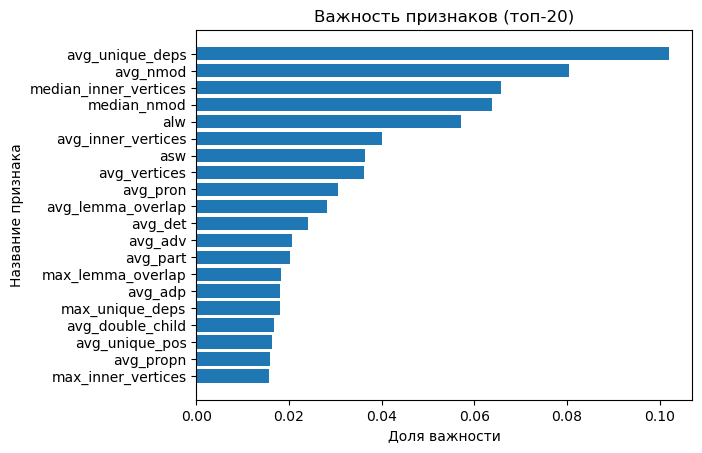

In [1504]:
import matplotlib.pyplot as plt

importances = xgb_model_best.feature_importances_

feature_names = feats_table_final.drop(columns=["text", "complexity"]).columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)

print(feat_imp.head(20))

plt.figure()
plt.barh(feat_imp['feature'][:20], feat_imp['importance'][:20])
plt.gca().invert_yaxis()
plt.title("Важность признаков (топ-20)")
plt.xlabel("Доля важности")
plt.ylabel("Название признака")
plt.show()

### Сравнение разных типов признаков

In [1012]:
structure_features = ["length", "avg_vertices", "asw", "alw"]
syntax_features = [
                    "avg_double_child", 
                    "avg_inner_vertices", 
                    "avg_tree_depth", 
                    "avg_amod", 
                    "avg_compound",
                    "avg_conj",
                    "avg_det",
                    "avg_nmod",
                    "avg_nsubj",
                    "avg_unique_deps",
                    "max_leaves",
                    "max_inner_vertices",
                    "max_vertices",
                    "max_unique_deps",
                    "median_nmod",
                    "median_inner_vertices",
                    "median_vertices",
                    "std_leaves",
                    "std_vertices",
                    "std_conj",
                    "std_det",
                    "std_mean_linear_distance"]
morph_features = [
                    "avg_adj",
                    "avg_adp",
                    "avg_adv",
                    "avg_aux",
                    "avg_cconj",
                    "avg_det_pos",
                    "avg_intj",
                    "avg_noun",
                    "avg_num",
                    "avg_part",
                    "avg_pron",
                    "avg_propn",
                    "avg_sconj",
                    "avg_verb",
                    "avg_unique_pos",
                    "max_unique_pos"
]

discursive_features = [
                    "avg_lemma_overlap",
                    "max_lemma_overlap"
]

In [1014]:
def train_and_evaluate(X_subset, y):
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=52)
    
    depth_list = [1, 2, 5, 10]
    max_leaf_list = [1, 2, 5, 7]
    learning_rate_list = [0.05, 0.1, 0.2, 0.4, 0.8, 1]
    lambda_list = [1, 5, 10, 20, 40]

    best_model_params = [1, 1, 0.05, 1]
    best_f1 = 0.1
    model_best = None

    random.seed(2025)
    np.random.seed(2025)
    etap = 0
    for depth in depth_list:
        for lr in learning_rate_list:
            for lambda_ in lambda_list:
                for max_leaf in max_leaf_list:
                    etap +=1
                    model_new = xgb.XGBClassifier(n_estimators = 200, random_state = 52, max_depth=depth, max_leaves=max_leaf, learning_rate = lr, reg_lambda = lambda_)
                    model_new.fit(X_train, y_train)
                    preds_new = model_new.predict(X_test)
                    f1_new = f1_score(y_test, preds_new, average = "weighted")
                    if f1_new > best_f1:
                        best_model_params = [depth, lr, lambda_, max_leaf]
                        best_f1 = f1_new
                        model_best = model_new

    best_depth = best_model_params[0]
    best_lr = best_model_params[1]
    best_lambda = best_model_params[2]
    best_max_leaf = best_model_params[3]

    model_best = xgb.XGBClassifier(n_estimators = 200, 
                          random_state = 52, 
                          max_depth=best_depth, 
                          max_leaves=best_max_leaf, 
                          learning_rate = best_lr,
                          reg_lambda = best_lambda)


    model_best.fit(X_train, y_train)

    y_pred = model_best.predict(X_test)
    
    class_report = classification_report(y_test, y_pred, zero_division = 1.0)
    
    return class_report

In [1016]:
results = {}

print("Fitting structure only")
results['structure_only'] = train_and_evaluate(feats_overall[structure_features], y)
print("Fitting structure + morph")
results["structure + morph"] = train_and_evaluate(feats_overall[structure_features + morph_features], y)
print("Fitting structure + discursive")
results["structure + discursive"] = train_and_evaluate(feats_overall[structure_features + discursive_features], y)
print("Fitting structure + morph + discursive")
results['structure + morph + discursive'] = train_and_evaluate(feats_overall[structure_features + morph_features + discursive_features], y)

print("Fitting morph only")
results['morph_only'] = train_and_evaluate(feats_overall[morph_features], y)
print("Fitting morph + syntax")
results['morph + syntax'] = train_and_evaluate(feats_overall[morph_features + syntax_features], y)
print("Fitting morph + discursive")
results['morph + discursive'] = train_and_evaluate(feats_overall[morph_features + discursive_features], y)
print("Fitting morph + syntax + discursive")
results['morph + syntax + discursive'] = train_and_evaluate(feats_overall[morph_features + syntax_features + discursive_features], y)

print("Fitting syntax only")
results['syntax_only'] = train_and_evaluate(feats_overall[syntax_features], y)
print("Fitting syntax + structure")
results['syntax + structure'] = train_and_evaluate(feats_overall[syntax_features + structure_features], y)
print("Fitting syntax + discursive")
results['syntax + discursive'] = train_and_evaluate(feats_overall[syntax_features + discursive_features], y)
print("Fitting syntax + structure + discursive")
results['syntax + structure + discursive'] = train_and_evaluate(feats_overall[syntax_features + structure_features + discursive_features], y)

print("Fitting discursive only")
results['discursive_only'] = train_and_evaluate(feats_overall[discursive_features], y)

print("Fitting structure + morph + syntax")
results['structure + morph + syntax'] = train_and_evaluate(feats_overall[structure_features + morph_features + syntax_features], y)

print("Fitting all features")
results['all_features'] = train_and_evaluate(feats_overall[feature_names], y)

Fitting structure only
Fitting structure + morph
Fitting structure + discursive
Fitting structure + morph + discursive
Fitting morph only
Fitting morph + syntax
Fitting morph + discursive
Fitting morph + syntax + discursive
Fitting syntax only
Fitting syntax + structure
Fitting syntax + discursive
Fitting syntax + structure + discursive
Fitting discursive only
Fitting structure + morph + syntax
Fitting all features


In [1020]:
for k, v in results.items():
    print(f"{k}:\n {v}")

structure_only:
               precision    recall  f1-score   support

           0       0.47      0.38      0.42       156
           1       0.33      0.24      0.28       215
           2       0.38      0.63      0.47       483
           3       0.37      0.21      0.27       344
           4       0.33      0.23      0.27       253

    accuracy                           0.37      1451
   macro avg       0.38      0.34      0.34      1451
weighted avg       0.37      0.37      0.35      1451

structure + morph:
               precision    recall  f1-score   support

           0       0.55      0.50      0.53       156
           1       0.46      0.36      0.40       215
           2       0.41      0.57      0.48       483
           3       0.39      0.28      0.33       344
           4       0.42      0.35      0.38       253

    accuracy                           0.43      1451
   macro avg       0.44      0.41      0.42      1451
weighted avg       0.43      0.43      0